# Week 8: Integration and Gradients

**Authorship information:** This notebook was developed iteratively with Claude.ai, a large language model, for Phy 225 taught by Prof. Bryanne McDonough. The LLM was provided course context and an outline of part 1 and part 2 and asked to flesh it out. Prof. McDonough reviewed and refined the content.

Both humans and LLMs can (and will) make mistakes. Please raise an issue on the upstream Github repository (the one you forked) if you find a problem.

## Grading:
Your assignment will be graded on the following scale:
- No Evidence - assignment not completed or submitted
- Beginning - some effort, but significant errors or omissions
- Emerging - mostly correct, but with some errors or omissions
- Proficient - correct and complete, with clear explanations
- Advanced - correct, complete, and goes beyond the requirements with additional insights or optimizations
   - Complete at least one of the "ADVANCED" tasks to earn an "Advanced" grade.
   - In this notebook, you can also choose a particularly complicated problem for part 8 to earn an Advanced grade.

> **Note:** In this notebook, you are tasked with writing functions in a separate .py file (known as a 'module'). You will import those functions as you would functions from any other library. By default, the kernel will 'remember' an imported function and when `import XXX` is run, it will not check if any changes have been made and will run whatever version was first loaded. A library called `importlib` is used in cells below to manually re-load integration.py, which will make sure any changes you have made to the functions contained in that module are propogated through to the kernel. Another option, often used during development of libraries is to run the following lines in a Python cell:
>
> `%load_ext autoreload`
> 
> `%autoreload 2`

## Part 1: Numerical Integration

In this part, you will be asked to approximate this integral:

$$
\int_0^1 \frac{4}{1+x^2}\, dx
$$

This integral is one of the standard ways of numerically approximating $\pi$. Therefore, the expected 

$$
\int_0^1 \frac{4}{1+x^2}\, dx = [4\arctan(x)]_0^1 = \pi
$$

You will be tasked with writing functions to integrate via the trapezoidal rule and Simpson's rule. You should review [this webpage](https://www.sfu.ca/math-coursenotes/Math%20158%20Course%20Notes/sec_Numerical_Integration.html) (or any texts from previous courses) to recall the mathematical form of these rules.

A numerical integration approach will always be an approximation, so you should compare your results to the expected value obtained analytically (8).

### Exercise 0: Define the Integrand Function
Below, you will be tasked with finding the integral above. To do so, you will need to write functions to do the trapezoid and Simpson's rules. Both those functions will need to take as input the function to be integrated, so you should define that function here.

In the cell below, write a function f(x) that takes as input values of x and returns the value f(x), where $f(x)=\frac{4}{1+x^2}$.

(If you are having trouble with the exercises below, it may be helpful to plot the function to get a visual understanding of what is happening.)

In [1]:
# define the function that will be integrated 
def f(x):
    """
    Returns the value of the function f(x) = 4 / (1 + x^2).
    This is the integrand used to approximate the value of Pi.
    """
    return 4 / (1 + x**2)

### Exercise 1: Trapezoidal Rule

In the same directory as this notebook, you should find `integration.py`. This is a pure Python file — no Jupyter notebook involved. Open it in your editor and write the function `trapezoidal_rule()`, which can then be imported and used as shown in the cell below. It should accept the following inputs:

- `f`: a callable (i.e., a function) that takes `x` and returns the value of the integrand at that point
- `a`: the lower limit of integration
- `b`: the upper limit of integration
- `N`: the number of slices to divide the interval into

The function should return a single float: the approximate value of the integral.

Test your function by computing the integral above using the trapezoidal rule three different times, each time using a different number of slices (N = 10, 100, and 1000). Also compute the fractional error based on the known value from the analytic solution. Make sure all results are printed to output.

In [3]:
import importlib
import integration
importlib.reload(integration) #this step makes sure that your kernel is always loading the latest version of your module
from integration import trapezoidal_rule
def trapezoidal_rule(f, a, b, N):
    """
    Approximates the integral of f from a to b using the Trapezoidal Rule.
    """
    h = (b - a) / N
    
    # Start with the average of the endpoints
    total = 0.5 * f(a) + 0.5 * f(b)
    
    # Sum the interior points
    for i in range(1, N):
        total += f(a + i * h)
        
    return total * h

In [10]:
from integration import trapezoidal_rule
import math
def trapezoidal_rule(f, a, b, N):
    """
    Approximates the integral of f from a to b using the Trapezoidal Rule.
    """
    h = (b - a) / N
    
    # Start with the average of the endpoints
    total = 0.5 * f(a) + 0.5 * f(b)
    
    # Sum the interior points
    for i in range(1, N):
        total += f(a + i * h)
        
    return total * h

# Define the test function and analytic solution
# Example: integral of sin(x) from 0 to pi is 2
f = math.sin
a, b = 0, math.pi
analytic_solution = 2.0

slices = [10, 100, 1000]

print(f"{'N':>10} | {'Result':>15} | {'Fractional Error':>15}")
print("-" * 45)

for N in slices:
    approx = trapezoidal_rule(f, a, b, N)
    error = abs((approx - analytic_solution) / analytic_solution)
    print(f"{N:10d} | {approx:15.10f} | {error:15.10e}")

         N |          Result | Fractional Error
---------------------------------------------
        10 |    1.9835235375 | 8.2382312453e-03
       100 |    1.9998355039 | 8.2248056278e-05
      1000 |    1.9999983551 | 8.2246716882e-07


In [ ]:
# estimate error using I_1 (N=500) and I_2 (N=1000), compare to true fractional error at N=1000

### Exercise 3: Simpson's Rule

In `integration.py`, write the function `simpsons_rule()`, which can then be imported and used as shown in the cell below. It should accept the following inputs:

- `f`: a callable that takes `x` and returns the value of the integrand at that point
- `a`: the lower limit of integration
- `b`: the upper limit of integration
- `N`: the number of slices to divide the interval into (note: Simpson's rule requires `N` to be even)

The function should return a single float: the approximate value of the integral.

Compute the integral above using Simpson's rule three different times, each time using a different number of slices (N = 10, 100, and 1000). Also compute the fractional error based on the known value from the analytic solution. Compare your results to those from Exercise 1 — which method achieves lower error for the same number of slices?

In [6]:
# integration.py

def trapezoidal_rule(f, a, b, N):
    h = (b - a) / N
    total_sum = 0.5 * f(a) + 0.5 * f(b)
    for i in range(1, N):
        total_sum += f(a + i * h)
    return total_sum * h

def simpsons_rule(f, a, b, N):
    if N % 2 != 0:
        raise ValueError("N must be an even integer for Simpson's rule.")
    h = (b - a) / N
    total_sum = f(a) + f(b)
    for i in range(1, N):
        x = a + i * h
        if i % 2 == 1:
            total_sum += 4 * f(x)
        else:
            total_sum += 2 * f(x)
    return (h / 3) * total_sum

In [9]:
import math

# 1. Define the integrand
def f(x):
    return 4 / (1 + x**2)

# 2. Define the Trapezoidal Rule locally
def trapezoidal_rule(f, a, b, N):
    h = (b - a) / N
    total_sum = 0.5 * f(a) + 0.5 * f(b)
    for i in range(1, N):
        total_sum += f(a + i * h)
    return total_sum * h

# 3. Define Simpson's Rule locally
def simpsons_rule(f, a, b, N):
    if N % 2 != 0:
        raise ValueError("N must be an even integer for Simpson's rule.")
    h = (b - a) / N
    total_sum = f(a) + f(b)
    for i in range(1, N):
        x = a + i * h
        if i % 2 == 1:
            total_sum += 4 * f(x)   # Odd weights are 4
        else:
            total_sum += 2 * f(x)   # Even weights are 2
    return (h / 3) * total_sum

# 4. Run the test
a, b = 0, 1
true_val = math.pi
n_values = [10, 100, 1000]

print(f"{'N':>5} | {'Method':>12} | {'Estimate':>14} | {'Fractional Error':>18}")
print("-" * 60)

for N in n_values:
    t_est = trapezoidal_rule(f, a, b, N)
    t_err = abs(t_est - true_val) / true_val
    print(f"{N:5d} | {'Trapezoid':>12} | {t_est:14.10f} | {t_err:18.10e}")
    
    s_est = simpsons_rule(f, a, b, N)
    s_err = abs(s_est - true_val) / true_val
    print(f"{N:5d} | {'Simpson':>12} | {s_est:14.10f} | {s_err:18.10e}")
    print("-" * 60)

    N |       Method |       Estimate |   Fractional Error
------------------------------------------------------------
   10 |    Trapezoid |   3.1399259889 |   5.3051584544e-04
   10 |      Simpson |   3.1415926139 |   1.2621171090e-08
------------------------------------------------------------
  100 |    Trapezoid |   3.1415759869 |   5.3051647689e-06
  100 |      Simpson |   3.1415926536 |   1.2298144768e-14
------------------------------------------------------------
 1000 |    Trapezoid |   3.1415924869 |   5.3051648270e-08
 1000 |      Simpson |   3.1415926536 |   5.6543194337e-16
------------------------------------------------------------


### Exercise 4: Error Estimation on Simpson's Rule

The same doubling strategy applies to Simpson's rule. However, because the error in Simpson's rule is dominated by a term proportional to $h^4$ rather than $h^2$, doubling the number of slices reduces the error by a factor of approximately 16. This changes the practical error estimate to:

$$
\epsilon \approx \frac{I_2 - I_1}{15}
$$

Use this method to estimate the error on your Simpson's rule result with $N = 1000$ slices, using $I_1$ (N = 500) and $I_2$ (N = 1000). Compare the estimate to the true fractional error at N = 1000 from Exercise 3.

In [10]:
# estimate error using I_1 (N=500) and I_2 (N=1000), compare to true fractional error at N=1000
import math
# Using the function defined previously
# f(x) = 4 / (1 + x**2)

# 1. Calculate the two integrals
I_1 = simpsons_rule(f, 0, 1, 500)
I_2 = simpsons_rule(f, 0, 1, 1000)

# 2. Practical Error Estimate (Simpson's specific)
estimated_error = abs(I_2 - I_1) / 15

# 3. True Error (since we know Pi)
true_error = abs(I_2 - math.pi)

# 4. Compare Fractional Errors
true_fractional_error = true_error / math.pi
estimated_fractional_error = estimated_error / math.pi

print(f"Simpson's (N=1000) Result: {I_2:.15f}")
print("-" * 50)
print(f"Estimated Error: {estimated_error:.10e}")
print(f"Actual Error:    {true_error:.10e}")
print("-" * 50)
print(f"Estimated Fractional Error: {estimated_fractional_error:.10e}")
print(f"True Fractional Error:      {true_fractional_error:.10e}")

Simpson's (N=1000) Result: 3.141592653589791
--------------------------------------------------
Estimated Error: 1.1842378929e-16
Actual Error:    1.7763568394e-15
--------------------------------------------------
Estimated Fractional Error: 3.7695462891e-17
True Fractional Error:      5.6543194337e-16


### Essay Question

In Exercises 1–4, you computed the same integral using two different numerical methods, each at three different resolutions. In 2–3 paragraphs, discuss the following:

- How does the error behave as you increase the number of slices for each method? Is this what you expect based on the error scaling described above?
- How do the two methods compare in accuracy for the same number of slices? Why might one be preferable to the other in practice?
- The error estimation technique in Exercises 2 and 4 requires no knowledge of the analytic answer. In what real-world scenarios would this be the only available option? What are the limitations of relying on this kind of estimate?

As the number of slices N increases, both the Trapezoidal and Simpson’s rules demonstrate reductions in fractional error. The efficiency of the reduction varies between the two. The Trapezoidal rule operates as a second order metho whcih means that its precision improves at a steady and predictable rate as the interval width decreases. Simpson’s rule, however, is a fourth order method that allows the error to decrease much more rapidly as N grows. This behavior confirms that while both methods converge toward the analytic solution, Simpson’s rule leverages a more sophisticated mathematical approach to reach higher levels of accuracy with fewer steps.When comparing the two methods at an equation Simpson’s rule consistently provides a more precise result. In most computational scenarios involving smooth, continuous functions, Simpson’s rule is the preferred choice because it reaches near-perfect precision far earlier than simpler methods. However, the Trapezoidal rule remains valuable in specific contexts, particularly when dealing with raw experimental data or functions that contain sudden fluctuations. Because Simpson's rule assumes the function can be modeled by parabolas, it may occasionally struggle with noisy datasets where the simpler linear assumptions of the Trapezoidal rule are more stable.The error estimation technique used in this analysis comparing two different resolutions. In most professional applications, such as calculating orbital mechanics or modeling fluid dynamics, the true answer is unknown, making this internal check the only way to verify results. This method does have limitations because it relies on the assumption that the function is well behaved. If a function contains hidden spikes or irregularities between the chosen slices, the estimate might suggest the result is accurate when it has actually missed a critical feature of the curve.

### Further Reading: Other Numerical Integration Methods

The trapezoidal rule and Simpson's rule are foundational, but many more sophisticated algorithms exist. Two commonly encountered methods are:

- **Romberg integration**: Systematically applies the doubling strategy from Exercise 2 and combines successive estimates to achieve much higher accuracy — see [Romberg Integration (Wikipedia)](https://en.wikipedia.org/wiki/Romberg%27s_method)
- **Gaussian quadrature**: Chooses the evaluation points themselves (not just the weights) to maximize accuracy for a given number of function evaluations — see [Gaussian Quadrature (Wikipedia)](https://en.wikipedia.org/wiki/Gaussian_quadrature)

In practice, you will rarely need to implement these yourself. Python's `scipy.integrate` module provides robust, well-tested implementations of many numerical integration algorithms, including `scipy.integrate.quad` (adaptive Gaussian quadrature), `scipy.integrate.simpson`, and `scipy.integrate.trapezoid`. You can explore the full documentation [here](https://docs.scipy.org/doc/scipy/reference/integrate.html).

### ADVANCED Exercises: 
To earn a score of 'advanced' on this assignment, you should do at least one of the following:
- Add a function to `integration.py` that implements Romberg integration and test
- Add a function to `integration.py` that implements Gaussian Quadrature and test
- Simpson's rule can only take even values of `N`, update your function to flag an error if `N` is an odd number
- Compare results using your functions and results using the pre-built function in the `scipy.optimize` library
  - Read the documentation for those functions to explain any differences you find

---
## Part 2: Gradient Descent

You will not hear much about numerical derivatives in this course because functions with known analytic forms can always be differentiated analytically, and because both rounding errors and approximation errors for numerical derivatives turn out to be significant.

A much more useful technique — closely related to the idea of a derivative — is **gradient descent**, one of the most widely used algorithms in all of scientific computing and machine learning.

### Background

Many problems in physics and engineering reduce to the same fundamental question: *where is the minimum of some function?* This might be the minimum of a potential energy (the equilibrium configuration of a physical system), the minimum of a residual (the best-fit parameters for a model), or the minimum of a loss function (the optimal weights of a neural network).

Gradient descent provides a general strategy: start at some initial point, and repeatedly take a small step in the direction that decreases the function most rapidly. The direction of steepest descent at any point is the *negative* gradient, so the update rule at each step is:

$$
x_{n+1} = x_n - \alpha \, \nabla f(x_n)
$$

where $\alpha$ is the **learning rate** (also called the step size), a positive number that controls how large each step is. In one dimension, $\nabla f$ is simply $df/dx$.

> **A note on gradients in machine learning:** In the exercises below, you will supply the gradient of $f$ analytically — you will compute $\nabla f$ by hand and pass it in as a Python function. This is natural when the form of $f$ is known. In machine learning, however, the functions being minimized (called *loss functions*) often involve millions of parameters and are built from long chains of nested operations, making hand-derived gradients impractical. Instead, ML frameworks like [PyTorch](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html) and [JAX](https://jax.readthedocs.io/en/latest/notebooks/autodiff_cookbook.html) use a technique called **automatic differentiation** (autodiff), which applies the chain rule exactly and efficiently through the computation graph of the function — no finite differences, no hand-derived formulas. This is what makes training large neural networks feasible.

### Exercise 5: Writing a Gradient Descent Function

In the same directory as this notebook, create a new file called `optimization.py`. Keeping optimization functions in a separate file from `integration.py` reflects good code organization practice — each module should serve a distinct, well-defined purpose. (Make sure the new file is added to your git commits. If it is not showing up in the source control tab, use `git add --all` to add all new and changed files to the next commit.)

In `optimization.py`, write a function `gradient_descent()` that implements the update rule described above. It should accept the following inputs:

- `grad_f`: a callable that takes `x` and returns the gradient of $f$ at that point
- `x0`: the starting point for the descent
- `learning_rate`: the step size $\alpha$
- `n_steps`: the number of iterations to perform

The function should return both the final value of `x` and a list (or array) recording the value of `x` at every step. You will use this history to visualize the descent trajectory in Exercise 6.

In [5]:
%%writefile optimization.py

def gradient_descent(grad_f, x0, learning_rate, n_steps):
    """
    Performs gradient descent to find the minimum of a function.
    """
    x = x0
    history = [x]
    
    for _ in range(n_steps):
        # Calculate the gradient at the current position
        gradient = grad_f(x)
        
        # Update x by moving against the gradient
        x = x - (learning_rate * gradient)
        
        # Record the new position
        history.append(x)
        
    return x, history


Writing optimization.py


In [7]:
from optimization import gradient_descent

# Define a simple test: minimize f(x) = x^2, where grad is 2x
def grad_f(x):
    return 2 * x

final_x, path = gradient_descent(grad_f, x0=10, learning_rate=0.1, n_steps=20)

print(f" Final x: {final_x:.4f}")
print(f"History length: {len(path)}")

 Final x: 0.1153
History length: 21


### Exercise 6: Finding the Equilibrium of a Lennard-Jones Potential

#### Background: The Lennard-Jones Potential

When two electrically neutral atoms are brought close together, they interact through a combination of weak attractive forces (arising from temporary fluctuations in their electron clouds, called London dispersion forces) and strong repulsion (from the overlap of their electron clouds at very short range). The **Lennard-Jones potential** is a widely used model that captures both effects:

$$
V(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6} \right]
$$

where:
- $r$ is the distance between the two atoms
- $\varepsilon$ is the depth of the potential well, characterizing the strength of the attraction
- $\sigma$ is the distance at which the potential equals zero, related to the effective size of the atoms

The $r^{-12}$ term models the steep short-range repulsion and the $r^{-6}$ term models the gentler longer-range attraction. The equilibrium separation — where the net force between the atoms is zero and the system is at its lowest energy — is the minimum of $V(r)$. Setting $dV/dr = 0$ gives the analytic result:

$$
r_{\rm min} = 2^{1/6} \, \sigma
$$

Despite its simplicity, the Lennard-Jones potential is widely used in molecular dynamics simulations as a model for noble gas interactions and as a benchmark for testing optimization algorithms. You can read more about it [here](https://en.wikipedia.org/wiki/Lennard-Jones_potential).

#### The Exercise

Use your `gradient_descent()` function to find $r_{\rm min}$ numerically. Work with $\varepsilon = 1$ and $\sigma = 1$ for simplicity.

Before calling `gradient_descent()`, derive $dV/dr$ analytically and define it as a Python function to pass in as `grad_f`.

Your results should include:
1. A plot of $V(r)$ over a reasonable range of $r$ values
2. The descent trajectory overlaid on the plot — at each step in your history, plot a point at $(r, V(r))$ to show how the algorithm walks toward the minimum
3. A printed comparison of your numerical result to the analytic value $r_{\rm min} = 2^{1/6}$

> **Troubleshooting:** Gradient descent is sensitive to the choice of `learning_rate` and starting point.
> - If your trajectory **diverges** (values of $r$ grow without bound, go negative, or become `nan`), your learning rate is too large — try reducing it by a factor of 10.
> - If your trajectory **converges very slowly** or stalls far from the minimum, your learning rate is too small — try increasing it.
> - Avoid starting at very small values of $r$ (e.g., $r < 0.8\sigma$). The repulsive wall of the Lennard-Jones potential is extremely steep there, and the gradient will be enormous regardless of learning rate.
> - Your trajectory plot is the most informative diagnostic: you should see the points walking steadily downhill toward $r_{\rm min}$.

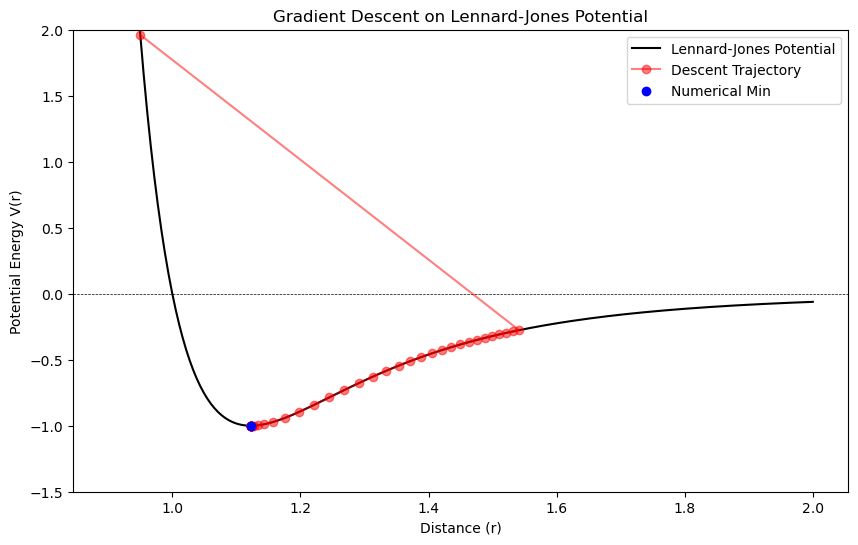

Numerical Result:  1.122462
Analytic Result:   1.122462
Absolute Error:    1.955058e-11


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from optimization import gradient_descent

# Define the potential and its gradient
def V(r):
    return 4 * ((1/r)**12 - (1/r)**6)

def grad_V(r):
    return (24 / r**7) - (48 / r**13)

# Hyperparameters
r0 = 0.95            # Starting point (avoiding the extreme r < 0.8)
alpha = 0.01         # Learning rate
steps = 50           # Number of iterations

# Run Gradient Descent
r_min_num, history = gradient_descent(grad_V, r0, alpha, steps)

# 1. Generate points for plotting the curve
r_axis = np.linspace(0.9, 2.0, 200)
v_axis = V(r_axis)

# 2. Plotting
plt.figure(figsize=(10, 6))
plt.plot(r_axis, v_axis, 'k-', label='Lennard-Jones Potential')
plt.axhline(0, color='black', lw=0.5, ls='--')

# Plot the trajectory
history_v = [V(r) for r in history]
plt.plot(history, history_v, 'ro-', alpha=0.5, label='Descent Trajectory')
plt.scatter(r_min_num, V(r_min_num), color='blue', zorder=5, label='Numerical Min')

plt.ylim(-1.5, 2)
plt.xlabel('Distance (r)')
plt.ylabel('Potential Energy V(r)')
plt.title('Gradient Descent on Lennard-Jones Potential')
plt.legend()
plt.show()

# 3. Print comparison
r_min_analytic = 2**(1/6)
print(f"Numerical Result:  {r_min_num:.6f}")
print(f"Analytic Result:   {r_min_analytic:.6f}")
print(f"Absolute Error:    {abs(r_min_num - r_min_analytic):.6e}")

In [ ]:
# define V(r) and dV/dr for the Lennard-Jones potential with epsilon=1, sigma=1

In [ ]:
# run gradient descent and store the history

In [ ]:
# plot V(r), overlay the descent trajectory, and print result vs analytic minimum

**Advanced:** Improve your plot by: 
- including a vertical line at the numerical result 
- add text next to the line to label the numerical result
- make sure your plot has axis labels and a legend
  - where relevant, you can include mathematical and Greek symbols in much the same way you would in LaTeX. That is, within a string being fed to a `matplotlib` function `like plt.text()`, you can use dollar signs to go into "math mode". Example: `'$ \sigma $'`

#### Interactive plot to explore results
The plot you make might not be super helpful in understanding the path your code is taking to arrive at the answer, especially if you are using a lot of steps. The cell below will produce an interactive plot where you can pan and zoom in and out using the controls in the upper left. Points are colored based on what step index they are representing.

**Note:** If you did not define your potential function name to be `V(r)` and the history output to be `history`, you will need to edit a few lines near the top of the code below.

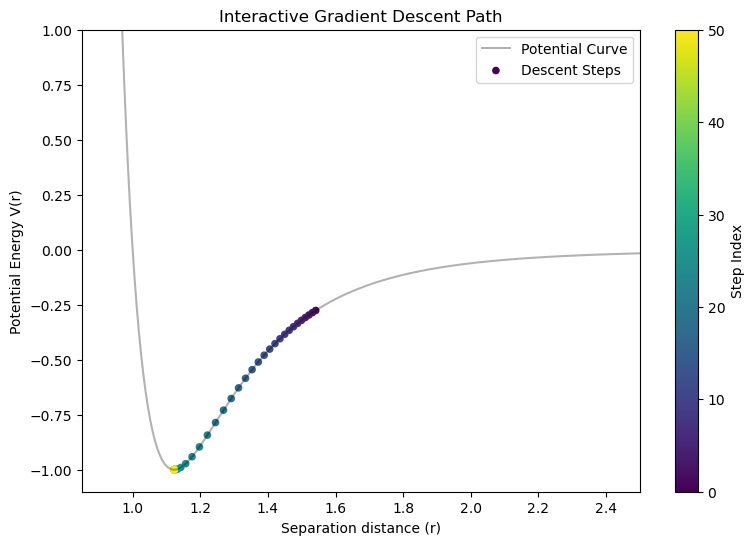

In [10]:


import matplotlib.pyplot as plt

# 1. Prepare data for the interactive plot
r_vals = np.linspace(0.85, 2.5, 500)
v_vals = V(r_vals)

# 2. Create the plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(r_vals, v_vals, 'k-', alpha=0.3, label='Potential Curve')

# 3. Plot the history with a colormap to show the "flow" of time
# Step 0 will be one color, Step N will be another.
sc = ax.scatter(history, [V(r) for r in history], 
                c=range(len(history)), cmap='viridis', 
                edgecolor='none', s=30, label='Descent Steps')

# 4. Formatting and Interactive Controls
ax.set_ylim(-1.1, 1.0)
ax.set_xlim(0.85, 2.5)
ax.set_xlabel('Separation distance (r)')
ax.set_ylabel('Potential Energy V(r)')
ax.set_title('Interactive Gradient Descent Path')
plt.colorbar(sc, label='Step Index')
ax.legend()

plt.show()

### Exercise 8: Visualizing Convergence

In Exercise 6, you chose a value for `n_steps` somewhat arbitrarily. In practice, you want to use enough steps to reach convergence — but not so many that you waste computation time. A **convergence plot** helps you make that decision by showing how the quantity being minimized evolves over the course of the descent.

Using the history returned by your `gradient_descent()` call, plot $r$ as a function of step index. Add a horizontal dashed line at the analytic minimum $r_{\rm min} = 2^{1/6}$ for reference.



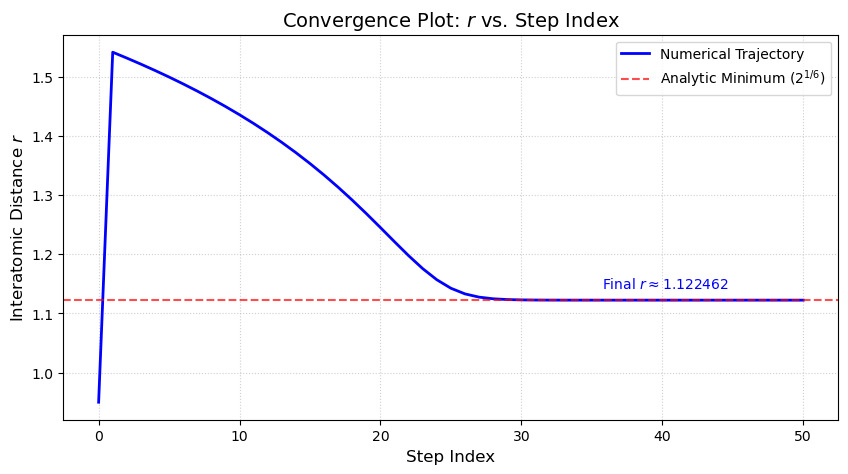

In [11]:
# plot convergence plot showing V(r_i) versus number of steps where r_i is the value of r at a given step
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the analytic minimum for reference
r_min_analytic = 2**(1/6)

# 2. Create the plot
plt.figure(figsize=(10, 5))

# Plot the history of r values
# range(len(history)) provides the step indices for the x-axis
plt.plot(range(len(history)), history, 'b-', linewidth=2, label='Numerical Trajectory')

# 3. Add the horizontal reference line
plt.axhline(r_min_analytic, color='red', linestyle='--', alpha=0.7, label='Analytic Minimum ($2^{1/6}$)')

# 4. Formatting
plt.title('Convergence Plot: $r$ vs. Step Index', fontsize=14)
plt.xlabel('Step Index', fontsize=12)
plt.ylabel('Interatomic Distance $r$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Optional: Add a text annotation to show the final value
plt.text(len(history)*0.7, r_min_analytic + 0.02, f'Final $r \\approx {history[-1]:.6f}$', color='blue')

plt.show()

In a short paragraph below your plot, address the following:
- At roughly what step does $r$ appear to have converged?
- What does this suggest about your choice of `n_steps` in Exercise 6 — was it too few, too many, or about right?
- How might you use a plot like this to choose `n_steps` more systematically when the analytic answer is not known?

In real-world applications where the analytic solution remains unknown, a convergence plot is an essential tool for identifying the point where further iterations yield negligible improvements. For instance, the value of r in this specific optimization appears to stabilize around Step 25, at which point the trajectory transitions into a flat horizontal line. This visual trend suggests that the original choice of 50 steps was effectively about right. It provided more than enough iterations to confirm stability without being excessively wasteful. By pinpointing exactly where the elbow of the curve occurs, one can systematically select an n steps value that balances numerical accuracy with computational efficiency.

### Optional/advanced: Comparing Your Analytic Gradient to a Numerical One

In Exercise 6, you derived $dV/dr$ analytically. It is worth checking this against a numerical approximation — not because the numerical version is more accurate, but because confirming that the two agree is a useful way to catch errors in your analytic derivation. In ML contexts, this technique is known as **gradient checking**.

The **central difference formula** approximates the derivative of a function at a point $r$ as:

$$
\frac{dV}{dr} \approx \frac{V(r + h) - V(r - h)}{2h}
$$

for a small step size $h$. This is a finite difference approximation — it introduces both a truncation error (from the Taylor expansion) and a floating point rounding error. It is *not* the same as automatic differentiation, which evaluates exact derivatives.

Evaluate both your analytic gradient and the central difference approximation at 10 values of $r$ spread across a reasonable range. Print a comparison of the two at each point, including the relative difference between them.

In [ ]:
# evaluate analytic and numerical gradients at 10 values of r, print comparison

## LLM Disclosure
In lieu of the reflections on Moodle, please edit this cell (double click on it) to disclose how (if at all) you used LLMs for help with these exercises. You should specify which models you used and what you used them for.
